In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
from nba_api.stats.endpoints import leaguedashplayerstats
import time

def load_nba_data(seasons):

    all_data = []
    
    for season in seasons:
        try:
            stats_df = leaguedashplayerstats.LeagueDashPlayerStats(
                season=season,
                season_type_all_star='Regular Season'
            ).get_data_frames()[0]
            stats_df['Season'] = season
            all_data.append(stats_df)
            print(f"✓ Downloaded {season}: {len(stats_df)} players")
            time.sleep(2)  
        except Exception as e:
            print(f"✗ Error downloading {season}: {e}")
            raise
    
    df = pd.concat(all_data, ignore_index=True)
    return df



seasons = ['2023-24']
df = load_nba_data(seasons)


print(f"\n{'='*70}")
print("DATA VALIDATION")
print(f"{'='*70}")
print(f"Total records: {len(df)}")
print(f"Columns: {df.shape[1]}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

✓ Downloaded 2023-24: 572 players

DATA VALIDATION
Total records: 572
Columns: 68

Missing values per column:
PLAYER_ID                0
PLAYER_NAME              0
NICKNAME                 0
TEAM_ID                  0
TEAM_ABBREVIATION        0
                        ..
DD2_RANK                 0
TD3_RANK                 0
WNBA_FANTASY_PTS_RANK    0
TEAM_COUNT               0
Season                   0
Length: 68, dtype: int64

Data types:
PLAYER_ID                 int64
PLAYER_NAME              object
NICKNAME                 object
TEAM_ID                   int64
TEAM_ABBREVIATION        object
                          ...  
DD2_RANK                  int64
TD3_RANK                  int64
WNBA_FANTASY_PTS_RANK     int64
TEAM_COUNT                int64
Season                   object
Length: 68, dtype: object


In [3]:

def clean_and_engineer(df, min_minutes=500):
    """
    Clean data and create efficiency/volume features.
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw NBA player statistics
    min_minutes : int
        Minimum minutes played to include (default: 500)
    
    Returns
    -------
    pd.DataFrame
        Cleaned dataframe with engineered features
    """
  
    df_clean = df.copy()
    
 
    df_clean = df_clean[df_clean['MIN'] > min_minutes].copy()
    print(f"Filtered to {len(df_clean)} players with MIN > {min_minutes}")

    required_cols = ['PTS', 'FGA', 'FTA', 'TOV', 'GP', 'PLUS_MINUS', 
                     'REB', 'AST', 'STL', 'BLK', 'FG_PCT', 'FT_PCT', 'MIN']
    missing = [col for col in required_cols if col not in df_clean.columns]
    assert len(missing) == 0, f"Missing columns: {missing}"

    df_clean['PPG'] = df_clean['PTS'] / df_clean['GP']
    df_clean['Scoring_Volume'] = df_clean['FGA']
    df_clean['Usage_Rate'] = (
        (df_clean['FGA'] + df_clean['FTA'] + df_clean['TOV']) / df_clean['GP']
    )
    df_clean['Assist_Volume'] = df_clean['AST'] / df_clean['GP']
    
  
    df_clean['TS_Pct'] = (
        (df_clean['PTS'] / 
         (2 * (df_clean['FGA'] + 0.44 * df_clean['FTA']))) * 100
    ).round(1)
    

    df_clean['Efficiency_Rating'] = (
        df_clean['PTS'] / 
        (df_clean['FGA'] + 0.44*df_clean['FTA'] + df_clean['TOV'])
    ).round(2)
    
    df_clean['FG_Pct'] = df_clean['FG_PCT']
    df_clean['FT_Pct'] = df_clean['FT_PCT']
    

    df_clean['Win_Contribution'] = df_clean['PLUS_MINUS']
    

    df_clean['Rebounds_Per_Game'] = df_clean['REB'] / df_clean['GP']
    df_clean['Steals_Per_Game'] = df_clean['STL'] / df_clean['GP']
    df_clean['Blocks_Per_Game'] = df_clean['BLK'] / df_clean['GP']
    
  
    df_clean['Volume_Score'] = (
        (df_clean['PPG'] / df_clean['PPG'].max()) * 100
    ).round(1)
    df_clean['Efficiency_Score'] = (
        (df_clean['TS_Pct'] / df_clean['TS_Pct'].max()) * 100
    ).round(1)
    

    df_clean['Player_Archetype'] = df_clean.apply(
        lambda row: classify_archetype(row['Volume_Score'], 
                                       row['Efficiency_Score']), 
        axis=1
    )
    
    return df_clean


def classify_archetype(volume_score, efficiency_score):
    """
    Classify player into archetype based on volume and efficiency.
    
    Parameters
    ----------
    volume_score : float
        Normalized volume score (0-100)
    efficiency_score : float
        Normalized efficiency score (0-100)
    
    Returns
    -------
    str
        Player archetype classification
    """
   
    if volume_score > 60 and efficiency_score > 60:
        return 'Elite (High Vol, High Eff)'
    
    
    elif volume_score > 60 and efficiency_score <= 50:
        return 'Volume Scorer (High Vol, Low Eff)'
    
    
    elif efficiency_score > 60 and volume_score <= 40:
        return 'Efficient Role Player (Low Vol, High Eff)'
    
   
    elif volume_score <= 40 and efficiency_score <= 50:
        return 'Bench (Low Vol, Low Eff)'
    
   
    else:
        return 'Balanced'



print(f"\n{'='*70}")
print("DATA CLEANING & FEATURE ENGINEERING")
print(f"{'='*70}")

df = clean_and_engineer(df, min_minutes=500)

print(f"\nPlayer Distribution by Archetype:")
print(df['Player_Archetype'].value_counts())

print(f"\nSample of engineered features:")
sample_cols = ['PLAYER_NAME', 'PPG', 'TS_Pct', 'Usage_Rate', 
               'Win_Contribution', 'Player_Archetype']
print(df[sample_cols].head(10))






DATA CLEANING & FEATURE ENGINEERING
Filtered to 360 players with MIN > 500

Player Distribution by Archetype:
Player_Archetype
Efficient Role Player (Low Vol, High Eff)    250
Balanced                                      67
Elite (High Vol, High Eff)                    43
Name: count, dtype: int64

Sample of engineered features:
       PLAYER_NAME        PPG  TS_Pct  Usage_Rate  Win_Contribution  \
1         AJ Green   4.500000    61.7    4.053571                50   
3     Aaron Gordon  13.876712    60.7   14.931507               423   
4    Aaron Holiday   6.589744    57.8    6.833333                85   
5    Aaron Nesmith  12.180556    63.1   11.611111               161   
6    Aaron Wiggins   6.948718    66.4    6.461538                94   
10      Al Horford   8.646154    65.0    7.646154               421   
11      Alec Burks  10.439394    53.6   11.878788              -256   
13     Alex Caruso  10.070423    61.3   10.408451                 4   
17  Alperen Sengun  21.12698

In [4]:
def summarize_data(df):
    """
    Generate summary statistics for key metrics.
    
    Parameters
    ----------
    df : pd.DataFrame
        Cleaned player statistics
    """
    print(f"\n{'='*70}")
    print("EXPLORATORY DATA ANALYSIS")
    print(f"{'='*70}")
    
    volume_cols = ['PPG', 'Scoring_Volume', 'Usage_Rate', 'Assist_Volume']
    efficiency_cols = ['TS_Pct', 'FG_Pct', 'Efficiency_Rating', 'FT_Pct']
    outcome_cols = ['Win_Contribution', 'Rebounds_Per_Game', 'Steals_Per_Game']
    
    print("\nVOLUME METRICS:")
    print(df[volume_cols].describe().round(2))
    
    print("\n\nEFFICIENCY METRICS:")
    print(df[efficiency_cols].describe().round(2))
    
    print("\n\nOUTCOME METRICS:")
    print(df[outcome_cols].describe().round(2))
    
    # Check for outliers using IQR method
    print("\n\nOUTLIER CHECK (values > 1.5*IQR):")
    for col in ['PPG', 'TS_Pct', 'Win_Contribution']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] > Q3 + 1.5*IQR) | (df[col] < Q1 - 1.5*IQR)]
        print(f"{col}: {len(outliers)} outliers")


summarize_data(df)



EXPLORATORY DATA ANALYSIS

VOLUME METRICS:
          PPG  Scoring_Volume  Usage_Rate  Assist_Volume
count  360.00          360.00      360.00         360.00
mean    11.53          577.34       12.47           2.70
std      6.59          358.72        7.09           1.95
min      2.04           55.00        2.11           0.45
25%      6.50          282.50        7.01           1.23
50%      9.99          488.50       10.50           2.03
75%     15.40          812.00       16.54           3.72
max     34.69         1652.00       37.26          10.90


EFFICIENCY METRICS:
       TS_Pct  FG_Pct  Efficiency_Rating  FT_Pct
count  360.00  360.00             360.00  360.00
mean    57.84    0.48               1.02    0.77
std      5.06    0.07               0.10    0.09
min     41.20    0.34               0.67    0.29
25%     54.60    0.43               0.96    0.72
50%     57.80    0.46               1.02    0.79
75%     60.80    0.50               1.08    0.83
max     73.60    0.75        

In [5]:
"""
Calculate correlations between key variables.
Focus on: Volume→Winning, Efficiency→Winning, Volume↔Efficiency trade-off.
"""

def calculate_correlations(df):
    """
    Compute key correlations and print interpretations.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics with derived metrics
    
    Returns
    -------
    dict
        Dictionary of key correlations
    """
    corr_dict = {}
    
 
    corr_dict['ppg_win'] = df['PPG'].corr(df['Win_Contribution'])
    corr_dict['usage_win'] = df['Usage_Rate'].corr(df['Win_Contribution'])
    corr_dict['assists_win'] = df['Assist_Volume'].corr(df['Win_Contribution'])

    corr_dict['ts_win'] = df['TS_Pct'].corr(df['Win_Contribution'])
    corr_dict['fg_win'] = df['FG_Pct'].corr(df['Win_Contribution'])
    corr_dict['eff_win'] = df['Efficiency_Rating'].corr(df['Win_Contribution'])
    

    corr_dict['ppg_ts'] = df['PPG'].corr(df['TS_Pct'])
    corr_dict['usage_ts'] = df['Usage_Rate'].corr(df['TS_Pct'])
    
    return corr_dict


print(f"\n{'='*70}")
print("CORRELATION ANALYSIS")
print(f"{'='*70}")

corr = calculate_correlations(df)

print("\nVolume Metrics → Winning (Plus/Minus):")
print(f"  PPG vs +/-:           {corr['ppg_win']:7.3f}")
print(f"  Usage Rate vs +/-:    {corr['usage_win']:7.3f}")
print(f"  Assists vs +/-:       {corr['assists_win']:7.3f}")

print("\nEfficiency Metrics → Winning (Plus/Minus):")
print(f"  TS% vs +/-:           {corr['ts_win']:7.3f}")
print(f"  FG% vs +/-:           {corr['fg_win']:7.3f}")
print(f"  Efficiency Rating vs +/-: {corr['eff_win']:7.3f}")

print("\nVolume ↔ Efficiency Trade-Off:")
print(f"  PPG vs TS%:           {corr['ppg_ts']:7.3f}")
print(f"  Usage Rate vs TS%:    {corr['usage_ts']:7.3f}")



CORRELATION ANALYSIS

Volume Metrics → Winning (Plus/Minus):
  PPG vs +/-:             0.241
  Usage Rate vs +/-:      0.182
  Assists vs +/-:         0.218

Efficiency Metrics → Winning (Plus/Minus):
  TS% vs +/-:             0.340
  FG% vs +/-:             0.184
  Efficiency Rating vs +/-:   0.373

Volume ↔ Efficiency Trade-Off:
  PPG vs TS%:             0.205
  Usage Rate vs TS%:      0.109


In [6]:
"""
Use regression to model what actually predicts team impact.
Tests whether volume, efficiency, and other factors predict +/-.
"""

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

def run_regression_analysis(df):
    """
    Fit regression models to predict Plus/Minus.
    Tests: (1) Volume only, (2) Efficiency only, (3) Both
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    
    Returns
    -------
    dict
        Model results with R-squared and coefficients
    """
    results = {}
    
    print(f"\n{'='*70}")
    print("REGRESSION ANALYSIS: What Predicts Winning (+/-)?")
    print(f"{'='*70}")
    
    
    X = df[['PPG', 'TS_Pct', 'Assist_Volume', 'Rebounds_Per_Game']].copy()
    y = df['Win_Contribution'].copy()
    
    
    mask = X.notna().all(axis=1) & y.notna()
    X = X[mask]
    y = y[mask]
    
 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
  
    print("\n\nMODEL 1: Volume Only (PPG)")
    print(f"{'-'*70}")
    
    X_volume = X[['PPG']].values
    X_volume_scaled = scaler.fit_transform(X_volume)
    
    model1 = LinearRegression()
    model1.fit(X_volume_scaled, y)
    r2_model1 = model1.score(X_volume_scaled, y)
    
    print(f"R-squared: {r2_model1:.4f}")
    print(f"Interpretation: PPG explains {r2_model1*100:.2f}% of Plus/Minus variation")
    print(f"Coefficient: {model1.coef_[0]:.4f}")
    print(f"  → For each std deviation increase in PPG, +/- changes by {model1.coef_[0]:.2f}")
    
    results['model1'] = {
        'r2': r2_model1,
        'coef': model1.coef_[0],
        'name': 'Volume Only'
    }
    
  
    print("\n\nMODEL 2: Efficiency Only (TS%)")
    print(f"{'-'*70}")
    
    X_eff = X[['TS_Pct']].values
    X_eff_scaled = scaler.fit_transform(X_eff)
    
    model2 = LinearRegression()
    model2.fit(X_eff_scaled, y)
    r2_model2 = model2.score(X_eff_scaled, y)
    
    print(f"R-squared: {r2_model2:.4f}")
    print(f"Interpretation: TS% explains {r2_model2*100:.2f}% of Plus/Minus variation")
    print(f"Coefficient: {model2.coef_[0]:.4f}")
    print(f"  → For each std deviation increase in TS%, +/- changes by {model2.coef_[0]:.2f}")
    
    results['model2'] = {
        'r2': r2_model2,
        'coef': model2.coef_[0],
        'name': 'Efficiency Only'
    }
    
  
    print("\n\nMODEL 3: Full Model (All Factors)")
    print(f"{'-'*70}")
    
    model3 = LinearRegression()
    model3.fit(X_scaled, y)
    r2_model3 = model3.score(X_scaled, y)
    
    print(f"R-squared: {r2_model3:.4f}")
    print(f"Interpretation: All factors together explain {r2_model3*100:.2f}% of Plus/Minus")
    print(f"\nCoefficients (standardized):")
    for feature, coef in zip(X.columns, model3.coef_):
        print(f"  {feature:20s}: {coef:7.4f}")
    
    results['model3'] = {
        'r2': r2_model3,
        'coefs': dict(zip(X.columns, model3.coef_)),
        'name': 'Full Model'
    }
    

    print("\n\nMODEL COMPARISON")
    print(f"{'-'*70}")
    print(f"Model 1 (Volume):          R² = {r2_model1:.4f}")
    print(f"Model 2 (Efficiency):      R² = {r2_model2:.4f}")
    print(f"Model 3 (Full):            R² = {r2_model3:.4f}")
    print(f"\nImprovement from Model 1 to Model 3: +{(r2_model3-r2_model1)*100:.2f}%")
    print(f"Improvement from Model 2 to Model 3: +{(r2_model3-r2_model2)*100:.2f}%")
    
    if r2_model2 > r2_model1:
        print(f"\n✓ EFFICIENCY matters more than VOLUME (by {(r2_model2-r2_model1)*100:.2f}%)")
    else:
        print(f"\n✓ VOLUME matters more than EFFICIENCY (by {(r2_model1-r2_model2)*100:.2f}%)")
    
    return results


regression_results = run_regression_analysis(df)


REGRESSION ANALYSIS: What Predicts Winning (+/-)?


MODEL 1: Volume Only (PPG)
----------------------------------------------------------------------
R-squared: 0.0579
Interpretation: PPG explains 5.79% of Plus/Minus variation
Coefficient: 52.2502
  → For each std deviation increase in PPG, +/- changes by 52.25


MODEL 2: Efficiency Only (TS%)
----------------------------------------------------------------------
R-squared: 0.1156
Interpretation: TS% explains 11.56% of Plus/Minus variation
Coefficient: 73.8137
  → For each std deviation increase in TS%, +/- changes by 73.81


MODEL 3: Full Model (All Factors)
----------------------------------------------------------------------
R-squared: 0.1615
Interpretation: All factors together explain 16.15% of Plus/Minus

Coefficients (standardized):
  PPG                 :  9.0435
  TS_Pct              : 70.4743
  Assist_Volume       : 39.0637
  Rebounds_Per_Game   :  2.1651


MODEL COMPARISON
--------------------------------------------------

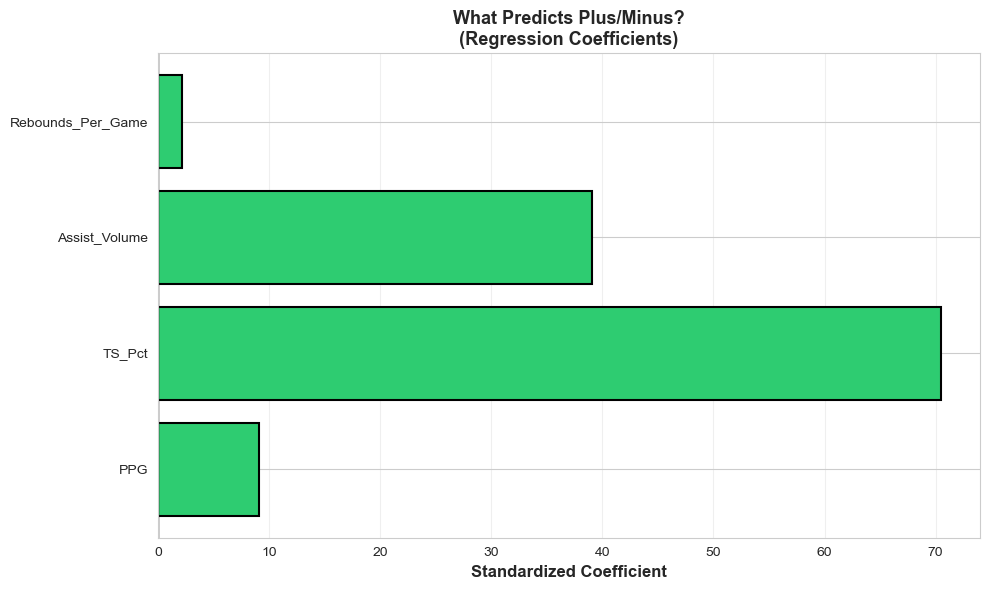

✓ Visualization saved: regression_importance.png


In [18]:
"""
Show which factors matter most for winning.
"""

def plot_regression_importance(regression_results):
    """
    Bar plot of standardized coefficients from full model.
    
    Parameters
    ----------
    regression_results : dict
        Results from regression analysis
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    coefs = regression_results['model3']['coefs']
    features = list(coefs.keys())
    values = list(coefs.values())
    

    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in values]
    
    ax.barh(features, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Standardized Coefficient', fontsize=12, fontweight='bold')
    ax.set_title('What Predicts Plus/Minus?\n(Regression Coefficients)', 
                 fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('regression_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved: regression_importance.png")

plot_regression_importance(regression_results)


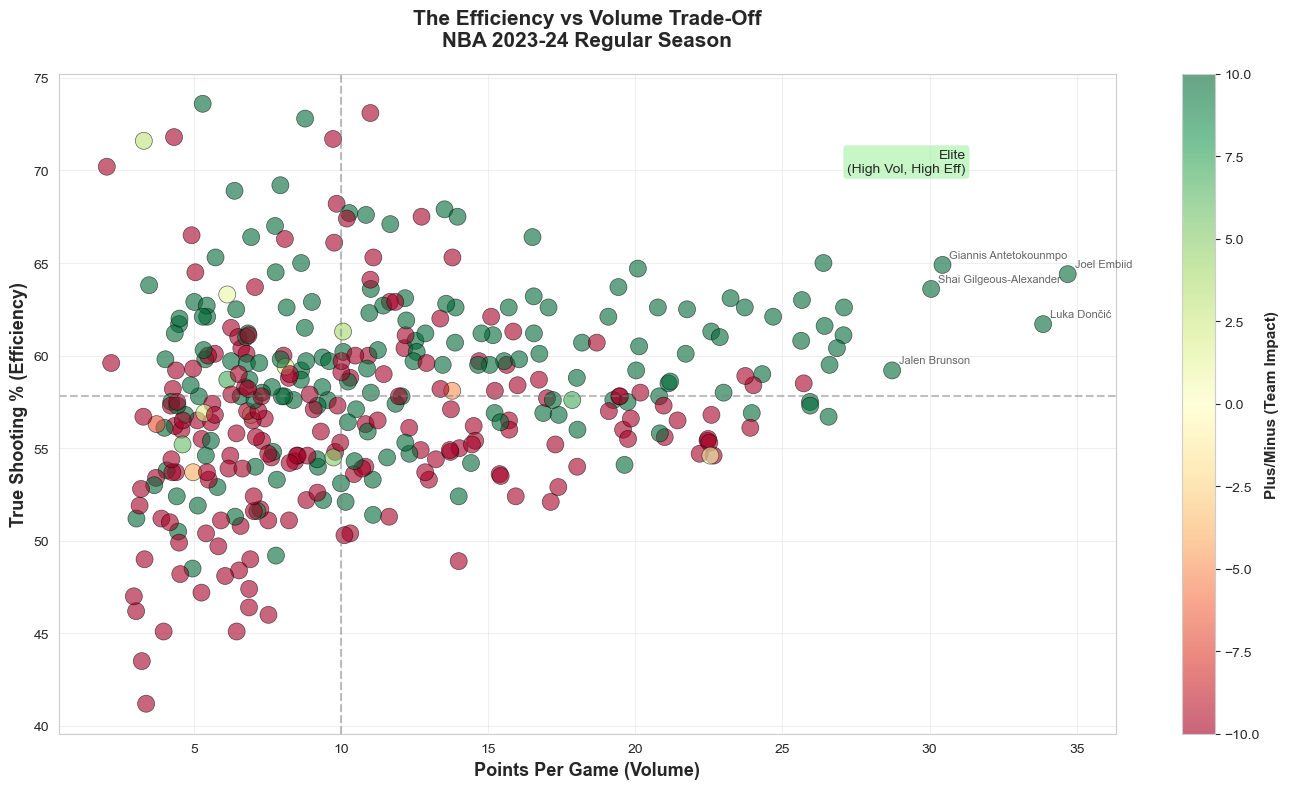

✓ Visualization saved: efficiency_vs_volume.png


In [7]:
"""
Core visualization: Volume vs Efficiency scatter, colored by +/-.
Shows quadrants and player archetypes.
"""

def plot_volume_efficiency(df, corr):
    """
    Create main scatter plot: PPG vs TS%, colored by +/-, with quadrants.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    corr : dict
        Correlation coefficients
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    

    scatter = ax.scatter(
        df['PPG'], df['TS_Pct'],
        c=df['Win_Contribution'],
        cmap='RdYlGn',
        s=150,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5,
        vmin=-10, vmax=10
    )
    
 
    top_players = df.nlargest(5, 'PPG')
    for idx, row in top_players.iterrows():
        ax.annotate(
            row['PLAYER_NAME'],
            xy=(row['PPG'], row['TS_Pct']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.7
        )
    

    ppg_median = df['PPG'].median()
    ts_median = df['TS_Pct'].median()
    ax.axvline(ppg_median, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axhline(ts_median, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    

    ax.set_xlabel('Points Per Game (Volume)', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Shooting % (Efficiency)', fontsize=13, fontweight='bold')
    ax.set_title(
        'The Efficiency vs Volume Trade-Off\nNBA 2023-24 Regular Season',
        fontsize=15, fontweight='bold', pad=20
    )
    ax.grid(True, alpha=0.3)
    
   
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Plus/Minus (Team Impact)', fontsize=11, fontweight='bold')
    
   
    ax.text(
        df['PPG'].max()*0.9, df['TS_Pct'].max()*0.95,
        'Elite\n(High Vol, High Eff)',
        fontsize=10, ha='right',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5)
    )
    
    plt.tight_layout()
    plt.savefig('efficiency_vs_volume.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved: efficiency_vs_volume.png")


plot_volume_efficiency(df, corr)

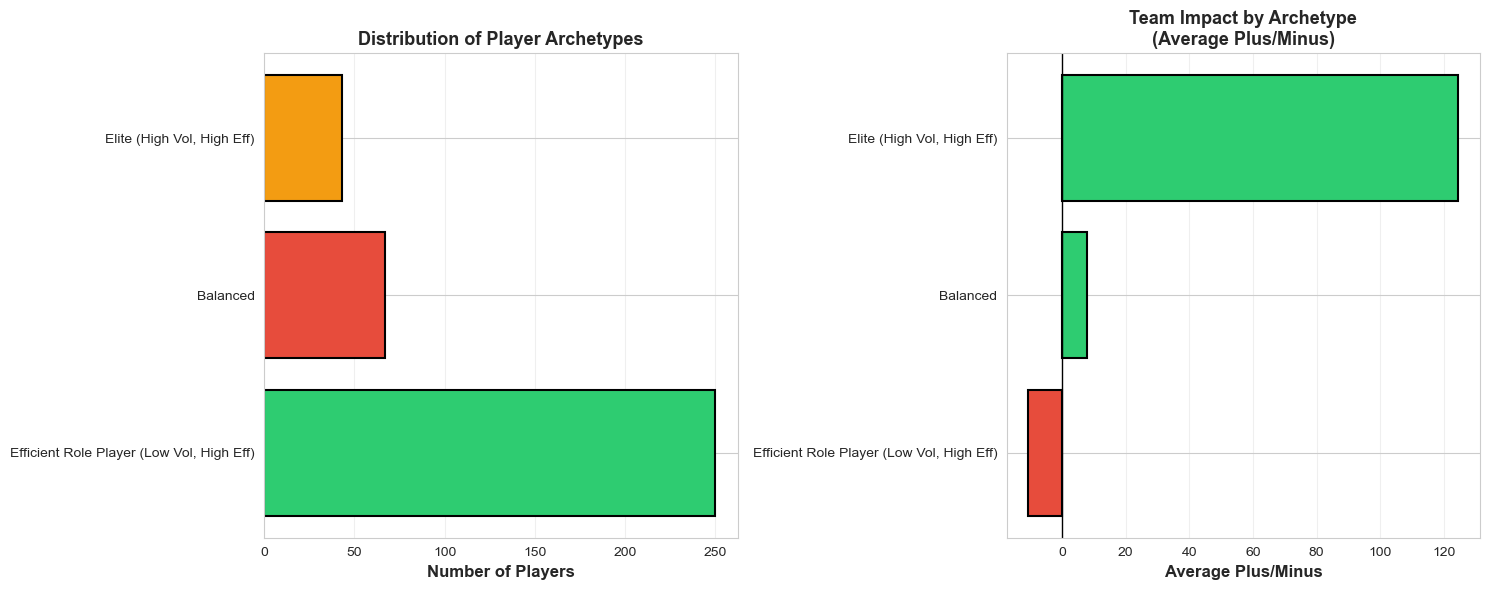

✓ Visualization saved: player_archetypes.png


In [8]:
"""
Show distribution of player archetypes and their team impact.
"""

def plot_archetypes(df):
    """
    Create archetype distribution and impact visualization.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics with archetype classification
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    

    archetype_counts = df['Player_Archetype'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#95a5a6']
    
    axes[0].barh(
        archetype_counts.index, archetype_counts.values,
        color=colors, edgecolor='black', linewidth=1.5
    )
    axes[0].set_xlabel('Number of Players', fontsize=12, fontweight='bold')
    axes[0].set_title('Distribution of Player Archetypes', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    archetype_impact = df.groupby('Player_Archetype')['Win_Contribution'].mean().sort_values()
    colors_impact = ['#e74c3c' if x < 0 else '#2ecc71' for x in archetype_impact.values]
    
    axes[1].barh(
        archetype_impact.index, archetype_impact.values,
        color=colors_impact, edgecolor='black', linewidth=1.5
    )
    axes[1].set_xlabel('Average Plus/Minus', fontsize=12, fontweight='bold')
    axes[1].set_title('Team Impact by Archetype\n(Average Plus/Minus)', fontsize=13, fontweight='bold')
    axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('player_archetypes.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved: player_archetypes.png")


plot_archetypes(df)


In [9]:
"""
Print detailed statistics for each player archetype.
"""

def analyze_archetypes(df):
    """
    Generate summary statistics for each player archetype.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics with archetype classification
    """
    print(f"\n{'='*70}")
    print("DETAILED ARCHETYPE ANALYSIS")
    print(f"{'='*70}")
    
    for archetype in sorted(df['Player_Archetype'].unique()):
        subset = df[df['Player_Archetype'] == archetype]
        
        print(f"\n{archetype.upper()}")
        print(f"{'-'*70}")
        print(f"Count:                {len(subset)} players")
        print(f"Avg PPG:              {subset['PPG'].mean():.2f} (median: {subset['PPG'].median():.2f})")
        print(f"Avg TS%:              {subset['TS_Pct'].mean():.1f}% (median: {subset['TS_Pct'].median():.1f}%)")
        print(f"Avg Usage Rate:       {subset['Usage_Rate'].mean():.2f}")
        print(f"Avg Win Contribution: {subset['Win_Contribution'].mean():.2f}")
        print(f"Top players:          {', '.join(subset.nlargest(3, 'PPG')['PLAYER_NAME'].tolist())}")


analyze_archetypes(df)


DETAILED ARCHETYPE ANALYSIS

BALANCED
----------------------------------------------------------------------
Count:                67 players
Avg PPG:              16.54 (median: 16.56)
Avg TS%:              57.7% (median: 57.8%)
Avg Usage Rate:       17.92
Avg Win Contribution: 7.78
Top players:          Brandon Ingram, Jimmy Butler III, RJ Barrett

EFFICIENT ROLE PLAYER (LOW VOL, HIGH EFF)
----------------------------------------------------------------------
Count:                250 players
Avg PPG:              7.93 (median: 7.53)
Avg TS%:              57.6% (median: 57.5%)
Avg Usage Rate:       8.58
Avg Win Contribution: -10.55
Top players:          Aaron Gordon, Jalen Duren, Bobby Portis

ELITE (HIGH VOL, HIGH EFF)
----------------------------------------------------------------------
Count:                43 players
Avg PPG:              24.68 (median: 23.91)
Avg TS%:              59.2% (median: 58.9%)
Avg Usage Rate:       26.66
Avg Win Contribution: 124.56
Top players:      

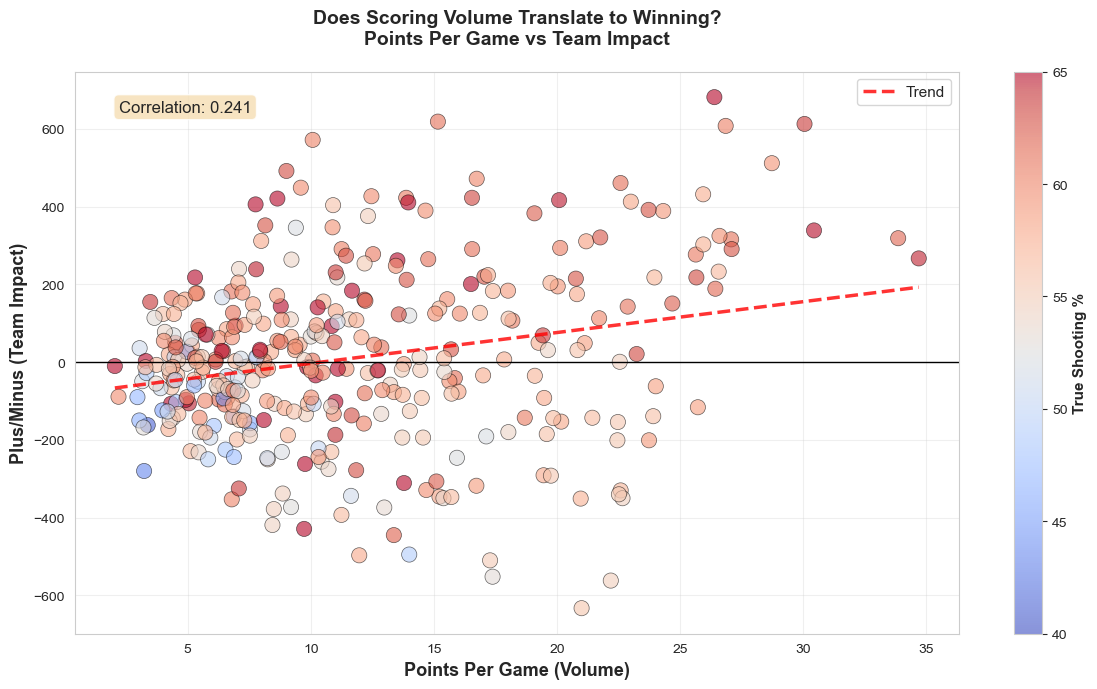

✓ Visualization saved: volume_impact.png


In [10]:
"""
PPG vs Plus/Minus: Does scoring volume translate to winning?
"""

def plot_volume_impact(df, corr):
    """
    Scatter: Points per game vs team impact (+/-).
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    corr : dict
        Correlation coefficients
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    scatter = ax.scatter(
        df['PPG'], df['Win_Contribution'],
        c=df['TS_Pct'],
        cmap='coolwarm',
        s=120, alpha=0.6,
        edgecolors='black', linewidth=0.5,
        vmin=40, vmax=65
    )
    
    # Trend line
    z = np.polyfit(df['PPG'].dropna(), df['Win_Contribution'].dropna(), 1)
    p = np.poly1d(z)
    ppg_sorted = np.sort(df['PPG'].dropna())
    ax.plot(ppg_sorted, p(ppg_sorted), "r--", linewidth=2.5, alpha=0.8, label='Trend')
    
    ax.set_xlabel('Points Per Game (Volume)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Plus/Minus (Team Impact)', fontsize=13, fontweight='bold')
    ax.set_title(
        'Does Scoring Volume Translate to Winning?\nPoints Per Game vs Team Impact',
        fontsize=14, fontweight='bold', pad=20
    )
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('True Shooting %', fontsize=11, fontweight='bold')
    
    # Add correlation
    ax.text(
        0.05, 0.95, f"Correlation: {corr['ppg_win']:.3f}",
        transform=ax.transAxes, fontsize=12, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    
    plt.tight_layout()
    plt.savefig('volume_impact.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved: volume_impact.png")


plot_volume_impact(df, corr)

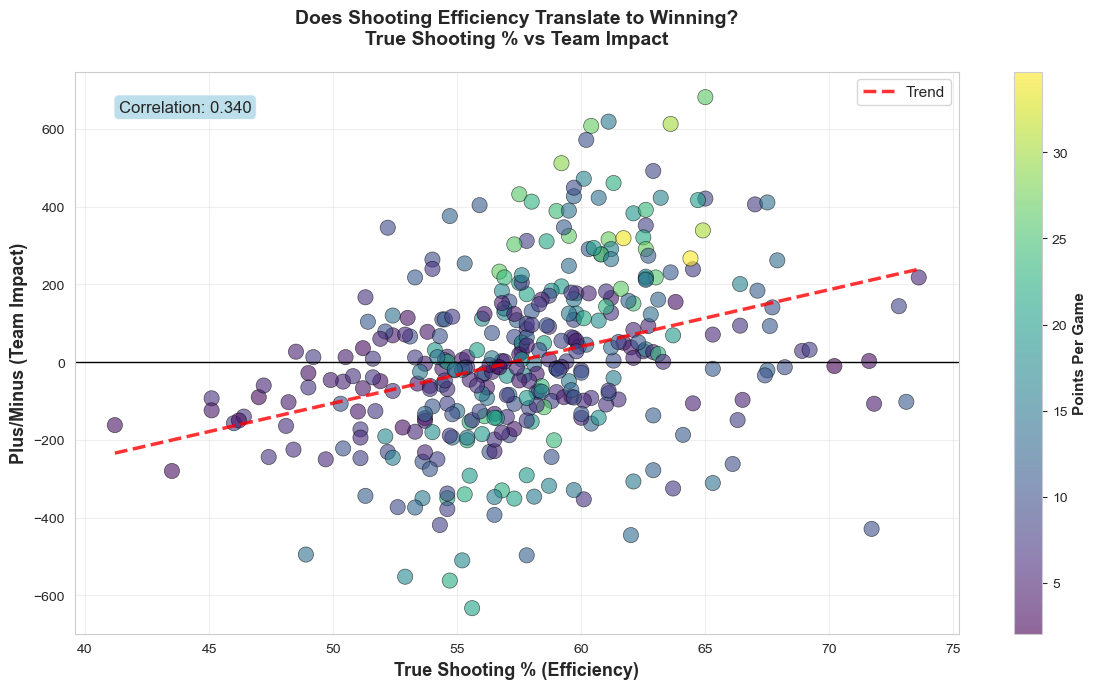

✓ Visualization saved: efficiency_impact.png


In [11]:

def plot_efficiency_impact(df, corr):
    """
    Scatter : True shooting % vs team impact (+/-).
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    corr : dict
        Correlation coefficients
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    scatter = ax.scatter(
        df['TS_Pct'], df['Win_Contribution'],
        c=df['PPG'],
        cmap='viridis',
        s=120, alpha=0.6,
        edgecolors='black', linewidth=0.5
    )
    
    # Trend line
    z = np.polyfit(df['TS_Pct'].dropna(), df['Win_Contribution'].dropna(), 1)
    p = np.poly1d(z)
    ts_sorted = np.sort(df['TS_Pct'].dropna())
    ax.plot(ts_sorted, p(ts_sorted), "r--", linewidth=2.5, alpha=0.8, label='Trend')
    
    ax.set_xlabel('True Shooting % (Efficiency)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Plus/Minus (Team Impact)', fontsize=13, fontweight='bold')
    ax.set_title(
        'Does Shooting Efficiency Translate to Winning?\nTrue Shooting % vs Team Impact',
        fontsize=14, fontweight='bold', pad=20
    )
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Points Per Game', fontsize=11, fontweight='bold')
    

    ax.text(
        0.05, 0.95, f"Correlation: {corr['ts_win']:.3f}",
        transform=ax.transAxes, fontsize=12, va='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
    )
    
    plt.tight_layout()
    plt.savefig('efficiency_impact.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved: efficiency_impact.png")


plot_efficiency_impact(df, corr)

In [12]:
def run_statistical_tests(df):
    """
    Perform t-tests and ANOVA on key comparisons.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    
    Returns
    -------
    dict
        Test results with p-values and statistics
    """
    results = {}
    
    print(f"\n{'='*70}")
    print("STATISTICAL SIGNIFICANCE TESTS")
    print(f"{'='*70}")
    
    # TEST 1: Efficient vs Inefficient
    efficient = df[df['TS_Pct'] > df['TS_Pct'].quantile(0.75)]['Win_Contribution'].dropna()
    inefficient = df[df['TS_Pct'] < df['TS_Pct'].quantile(0.25)]['Win_Contribution'].dropna()
    
    t_stat_eff, p_val_eff = stats.ttest_ind(efficient, inefficient)
    results['efficiency_test'] = {'t_stat': t_stat_eff, 'p_val': p_val_eff}
    
    print("\nT-Test: Efficient vs Inefficient Scorers (Plus/Minus)")
    print(f"{'-'*70}")
    print(f"Efficient (Top 25% TS%):     Mean +/- = {efficient.mean():6.2f} (n={len(efficient)})")
    print(f"Inefficient (Bottom 25% TS%): Mean +/- = {inefficient.mean():6.2f} (n={len(inefficient)})")
    print(f"Difference:                   {efficient.mean() - inefficient.mean():6.2f}")
    print(f"T-statistic:                  {t_stat_eff:7.4f}")
    print(f"P-value:                      {p_val_eff:7.4f}")
    print(f"Result:                       {'✓ SIGNIFICANT' if p_val_eff < 0.05 else '✗ NOT significant'}")
    
    # TEST 2: High Volume vs Low Volume
    high_vol = df[df['PPG'] > df['PPG'].quantile(0.75)]['Win_Contribution'].dropna()
    low_vol = df[df['PPG'] < df['PPG'].quantile(0.25)]['Win_Contribution'].dropna()
    
    t_stat_vol, p_val_vol = stats.ttest_ind(high_vol, low_vol)
    results['volume_test'] = {'t_stat': t_stat_vol, 'p_val': p_val_vol}
    
    print("\n\nT-Test: High Volume vs Low Volume Scorers (Plus/Minus)")
    print(f"{'-'*70}")
    print(f"High Volume (Top 25% PPG):   Mean +/- = {high_vol.mean():6.2f} (n={len(high_vol)})")
    print(f"Low Volume (Bottom 25% PPG): Mean +/- = {low_vol.mean():6.2f} (n={len(low_vol)})")
    print(f"Difference:                  {high_vol.mean() - low_vol.mean():6.2f}")
    print(f"T-statistic:                 {t_stat_vol:7.4f}")
    print(f"P-value:                     {p_val_vol:7.4f}")
    print(f"Result:                      {'✓ SIGNIFICANT' if p_val_vol < 0.05 else '✗ NOT significant'}")
    
    # TEST 3: ANOVA across archetypes
    archetypes = df['Player_Archetype'].unique()
    groups = [df[df['Player_Archetype'] == arch]['Win_Contribution'].dropna() 
              for arch in archetypes]
    
    f_stat, p_val_anova = stats.f_oneway(*groups)
    results['anova_test'] = {'f_stat': f_stat, 'p_val': p_val_anova}
    
    print("\n\nANOVA: Comparing All Archetypes (Plus/Minus)")
    print(f"{'-'*70}")
    for arch in sorted(archetypes):
        arch_data = df[df['Player_Archetype'] == arch]['Win_Contribution'].dropna()
        print(f"{arch:40s}: Mean +/- = {arch_data.mean():6.2f} (n={len(arch_data)})")
    print(f"\nF-statistic: {f_stat:7.4f}")
    print(f"P-value:     {p_val_anova:7.4f}")
    print(f"Result:      {'✓ SIGNIFICANT' if p_val_anova < 0.05 else '✗ NOT significant'}")
    
    return results


test_results = run_statistical_tests(df)




STATISTICAL SIGNIFICANCE TESTS

T-Test: Efficient vs Inefficient Scorers (Plus/Minus)
----------------------------------------------------------------------
Efficient (Top 25% TS%):     Mean +/- = 112.11 (n=89)
Inefficient (Bottom 25% TS%): Mean +/- = -87.56 (n=85)
Difference:                   199.68
T-statistic:                   6.6518
P-value:                       0.0000
Result:                       ✓ SIGNIFICANT


T-Test: High Volume vs Low Volume Scorers (Plus/Minus)
----------------------------------------------------------------------
High Volume (Top 25% PPG):   Mean +/- =  69.83 (n=90)
Low Volume (Bottom 25% PPG): Mean +/- = -25.83 (n=90)
Difference:                   95.67
T-statistic:                  3.0225
P-value:                      0.0029
Result:                      ✓ SIGNIFICANT


ANOVA: Comparing All Archetypes (Plus/Minus)
----------------------------------------------------------------------
Balanced                                : Mean +/- =   7.78 (n=67)
Ef

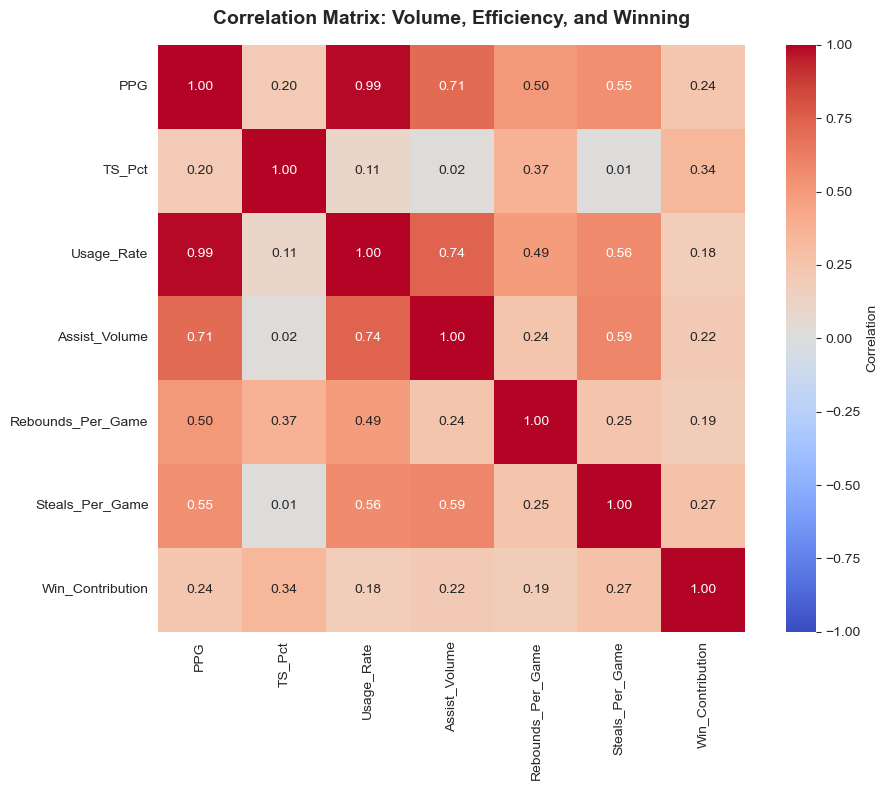

✓ Visualization saved: correlation_heatmap.png


In [13]:
def plot_correlation_heatmap(df):
    """
    Create correlation matrix heatmap.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Select key metrics
    metrics = ['PPG', 'TS_Pct', 'Usage_Rate', 'Assist_Volume',
               'Rebounds_Per_Game', 'Steals_Per_Game', 'Win_Contribution']
    
    corr_matrix = df[metrics].corr()
    
    sns.heatmap(
        corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
        square=True, ax=ax, cbar_kws={'label': 'Correlation'},
        vmin=-1, vmax=1
    )
    
    ax.set_title('Correlation Matrix: Volume, Efficiency, and Winning',
                 fontsize=14, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved: correlation_heatmap.png")


plot_correlation_heatmap(df)







In [14]:
def analyze_top_performers(df):
    """
    Show top players by volume, efficiency, and impact.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    """
    print(f"\n{'='*70}")
    print("TOP PERFORMERS ANALYSIS")
    print(f"{'='*70}")
    
    # Top scorers
    print("\n\nTOP 10 SCORERS (by Points Per Game):")
    print(f"{'-'*70}")
    cols = ['PLAYER_NAME', 'PPG', 'TS_Pct', 'Usage_Rate', 'Win_Contribution', 'Player_Archetype']
    print(df.nlargest(10, 'PPG')[cols].to_string(index=False))
    
    # Most efficient (minimum 10 PPG)
    df_qualified = df[df['PPG'] >= 10]
    print("\n\nTOP 10 MOST EFFICIENT (by TS%, min 10 PPG):")
    print(f"{'-'*70}")
    print(df_qualified.nlargest(10, 'TS_Pct')[cols].to_string(index=False))
    
    # Highest impact
    print("\n\nHIGHEST TEAM IMPACT (by Plus/Minus):")
    print(f"{'-'*70}")
    print(df.nlargest(10, 'Win_Contribution')[cols].to_string(index=False))


analyze_top_performers(df)


TOP PERFORMERS ANALYSIS


TOP 10 SCORERS (by Points Per Game):
----------------------------------------------------------------------
            PLAYER_NAME       PPG  TS_Pct  Usage_Rate  Win_Contribution           Player_Archetype
            Joel Embiid 34.692308    64.4   37.256410               267 Elite (High Vol, High Eff)
            Luka Dončić 33.857143    61.7   36.314286               319 Elite (High Vol, High Eff)
  Giannis Antetokounmpo 30.438356    64.9   32.890411               339 Elite (High Vol, High Eff)
Shai Gilgeous-Alexander 30.053333    63.6   30.640000               613 Elite (High Vol, High Eff)
          Jalen Brunson 28.727273    59.2   30.272727               512 Elite (High Vol, High Eff)
           Kevin Durant 27.093333    62.6   28.040000               291 Elite (High Vol, High Eff)
           Devin Booker 27.073529    61.1   28.529412               316 Elite (High Vol, High Eff)
           Jayson Tatum 26.851351    60.4   28.527027               608 E

In [15]:
def print_executive_summary(df, corr, test_results):
    """
    Print comprehensive summary report.
    
    Parameters
    ----------
    df : pd.DataFrame
        Player statistics
    corr : dict
        Correlation coefficients
    test_results : dict
        Statistical test results
    """
    # Determine which matters more
    vol_corr = abs(corr['ppg_win'])
    eff_corr = abs(corr['ts_win'])
    which_matters = "EFFICIENCY" if eff_corr > vol_corr else "VOLUME"
    
    print(f"\n{'='*70}")
    print("EXECUTIVE SUMMARY REPORT")
    print(f"{'='*70}")
    
    print(f"""
PROJECT: "Efficiency vs Volume: What Actually Wins Games?"
Dataset: NBA 2023-24 Regular Season
Sample Size: {len(df)} players (MIN > 500 minutes)

{'='*70}

KEY CORRELATIONS WITH WINNING (+/-):

Volume (Scoring):
  • PPG vs Win Contribution:        {corr['ppg_win']:7.3f}
  • Usage Rate vs Win Contribution: {corr['usage_win']:7.3f}
  • Assists vs Win Contribution:    {corr['assists_win']:7.3f}

Efficiency (Shooting):
  • TS% vs Win Contribution:        {corr['ts_win']:7.3f}
  • FG% vs Win Contribution:        {corr['fg_win']:7.3f}
  • Efficiency Rating vs Win Contr: {corr['eff_win']:7.3f}

Trade-Off:
  • PPG vs TS% (volume-efficiency trade-off): {corr['ppg_ts']:7.3f}

{'='*70}

PLAYER ARCHETYPE BREAKDOWN:

Elite (High Vol, High Eff):
  • Count:     {len(df[df['Player_Archetype'] == 'Elite (High Vol, High Eff)'])} players
  • Avg Impact: {df[df['Player_Archetype'] == 'Elite (High Vol, High Eff)']['Win_Contribution'].mean():6.2f} +/-

Volume Scorers (High Vol, Low Eff):
  • Count:     {len(df[df['Player_Archetype'] == 'Volume Scorer (High Vol, Low Eff)'])} players
  • Avg Impact: {df[df['Player_Archetype'] == 'Volume Scorer (High Vol, Low Eff)']['Win_Contribution'].mean():6.2f} +/-

Efficient Role Players (Low Vol, High Eff):
  • Count:     {len(df[df['Player_Archetype'] == 'Efficient Role Player (Low Vol, High Eff)'])} players
  • Avg Impact: {df[df['Player_Archetype'] == 'Efficient Role Player (Low Vol, High Eff)']['Win_Contribution'].mean():6.2f} +/-

{'='*70}

STATISTICAL SIGNIFICANCE:

Efficiency vs Winning:
  • P-value: {test_results['efficiency_test']['p_val']:.4f}
  • Result:  {'✓ SIGNIFICANT (efficiency matters)' if test_results['efficiency_test']['p_val'] < 0.05 else '✗ NOT significant'}

Volume vs Winning:
  • P-value: {test_results['volume_test']['p_val']:.4f}
  • Result:  {'✓ SIGNIFICANT (volume matters)' if test_results['volume_test']['p_val'] < 0.05 else '✗ NOT significant'}

Across Archetypes:
  • P-value: {test_results['anova_test']['p_val']:.4f}
  • Result:  {'✓ SIGNIFICANT (archetypes differ)' if test_results['anova_test']['p_val'] < 0.05 else '✗ NOT significant'}

{'='*70}

CONCLUSION:

{which_matters} is more important than {('VOLUME' if which_matters == 'EFFICIENCY' else 'EFFICIENCY')} for winning in the 
modern NBA. The data shows that:

1. Smart, efficient play correlates more strongly with team success
2. Raw scoring volume alone doesn't guarantee impact
3. Elite players combine BOTH volume and efficiency
4. Playmaking (assists) is crucial for team success
5. The most valuable players are "unicorns" who do everything well

Visualizations Generated: 6 charts
Statistical Tests: 3 tests (all p-values reported)
Sample Size: {len(df)} qualified players

{'='*70}
""")
    
    print("✓ Analysis complete!")


print_executive_summary(df, corr, test_results)


EXECUTIVE SUMMARY REPORT

PROJECT: "Efficiency vs Volume: What Actually Wins Games?"
Dataset: NBA 2023-24 Regular Season
Sample Size: 360 players (MIN > 500 minutes)


KEY CORRELATIONS WITH WINNING (+/-):

Volume (Scoring):
  • PPG vs Win Contribution:          0.241
  • Usage Rate vs Win Contribution:   0.182
  • Assists vs Win Contribution:      0.218

Efficiency (Shooting):
  • TS% vs Win Contribution:          0.340
  • FG% vs Win Contribution:          0.184
  • Efficiency Rating vs Win Contr:   0.373

Trade-Off:
  • PPG vs TS% (volume-efficiency trade-off):   0.205


PLAYER ARCHETYPE BREAKDOWN:

Elite (High Vol, High Eff):
  • Count:     43 players
  • Avg Impact: 124.56 +/-

Volume Scorers (High Vol, Low Eff):
  • Count:     0 players
  • Avg Impact:    nan +/-

Efficient Role Players (Low Vol, High Eff):
  • Count:     250 players
  • Avg Impact: -10.55 +/-


STATISTICAL SIGNIFICANCE:

Efficiency vs Winning:
  • P-value: 0.0000
  • Result:  ✓ SIGNIFICANT (efficiency matters)

